# Multivariate Gaussian Mixture Model (GMM) Regime Segmentation

This notebook implements **Gaussian Mixture Model (GMM)** estimated via the **Expectation-Maximization (EM)** algorithm for market regime segmentation.

- **Bull Market** — strong equity returns, lower volatility, healthy macro fundamentals
- **Bear Market** — negative equity returns, surging volatility, macroeconomic stress

---
## Data Loading & Inspection

In [393]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import matplotlib.dates as mdates

# Load data
data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Data loaded. Shape: (8107, 26)
Date range: 1994-01-27 to 2026-04-15

Columns: ['Date', 'GSPC', 'VIX', 'SPY Volume', 'Oil', 'GDP', 'Core_Inflation', 'Unemployment', 'M2', 'Sentiment', 'Return', 'Return_5d', 'Return_20d', 'Return_Smooth', 'RSI_14', 'MACD_Line', 'MACD_Signal', 'MACD_Hist', 'GDP_YoY', 'Core_Inflation_YoY', 'M2_YoY', 'Peak', 'Drawdown', 'VIX_Change', 'VIX_Change_5d', 'Regime']


,Date,GSPC,VIX,SPY Volume,Oil,GDP,Core_Inflation,Unemployment,M2,Sentiment,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,1994-01-27,477.049988,10.30,344500.0,15.48,10939.116,66.902,6.6,3474.9,94.3,...,1.997186,-0.061014,0.034307,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,NaN
1,1994-01-28,478.700012,9.94,356500.0,15.37,10939.116,66.902,6.6,3474.9,94.3,...,2.041544,0.177433,0.034307,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,NaN
2,1994-01-31,481.609985,10.63,313800.0,15.24,10939.116,66.902,6.6,3474.9,94.3,...,2.162714,0.484681,0.034307,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,NaN
3,1994-02-01,479.619995,10.65,303600.0,15.91,10939.116,67.047,6.6,3475.7,93.2,...,2.288998,0.505137,0.034307,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,NaN
4,1994-02-02,482.000000,10.61,307600.0,16.06,10939.116,67.047,6.6,3475.7,93.2,...,2.444622,0.622496,0.034307,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,NaN


We fetch consumer sentiment from FRED

In [394]:
import os
from dotenv import load_dotenv
from fredapi import Fred

load_dotenv()
fred = Fred(api_key='edf185d621148e61f50e97f856494963')

sentiment = fred.get_series('UMCSENT').to_frame('Consumer_Sentiment')
sentiment.index = pd.to_datetime(sentiment.index)
sentiment = sentiment.resample('D').ffill()

df = df.merge(sentiment, left_on='Date', right_index=True, how='left')
df['Consumer_Sentiment'] = df['Consumer_Sentiment'].ffill().bfill()

# ── Derived sentiment features ──────────────────────────────────────
# 1. Month-over-month change (21 trading days ≈ 1 calendar month)
#    Captures the DIRECTION of sentiment shifts — a sharp drop precedes recessions
df['Consumer_Sentiment_MoM'] = df['Consumer_Sentiment'].diff(21)

# 2. Rolling 12-month z-score (252 trading days)
#    Captures whether sentiment is unusually high/low relative to recent history
rolling_mean = df['Consumer_Sentiment'].rolling(252, min_periods=63).mean()
rolling_std  = df['Consumer_Sentiment'].rolling(252, min_periods=63).std()
df['Consumer_Sentiment_ZScore'] = (df['Consumer_Sentiment'] - rolling_mean) / rolling_std

print(f"Consumer Sentiment merged. Shape: {df.shape}")
print(f"Consumer_Sentiment NaNs:        {df['Consumer_Sentiment'].isna().sum()}")
print(f"Consumer_Sentiment_MoM NaNs:    {df['Consumer_Sentiment_MoM'].isna().sum()}")
print(f"Consumer_Sentiment_ZScore NaNs: {df['Consumer_Sentiment_ZScore'].isna().sum()}")

Consumer Sentiment merged. Shape: (8107, 29)
Consumer_Sentiment NaNs:        0
Consumer_Sentiment_MoM NaNs:    21
Consumer_Sentiment_ZScore NaNs: 62


In [395]:
# Remove and add back regime column
df.drop(columns=['Regime'], inplace=True)
df.head()

,Date,GSPC,VIX,SPY Volume,Oil,GDP,Core_Inflation,Unemployment,M2,Sentiment,...,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Consumer_Sentiment,Consumer_Sentiment_MoM,Consumer_Sentiment_ZScore
0,1994-01-27,477.049988,10.30,344500.0,15.48,10939.116,66.902,6.6,3474.9,94.3,...,0.034307,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,94.3,NaN,NaN
1,1994-01-28,478.700012,9.94,356500.0,15.37,10939.116,66.902,6.6,3474.9,94.3,...,0.034307,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,94.3,NaN,NaN
2,1994-01-31,481.609985,10.63,313800.0,15.24,10939.116,66.902,6.6,3474.9,94.3,...,0.034307,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,94.3,NaN,NaN
3,1994-02-01,479.619995,10.65,303600.0,15.91,10939.116,67.047,6.6,3475.7,93.2,...,0.034307,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,93.2,NaN,NaN
4,1994-02-02,482.000000,10.61,307600.0,16.06,10939.116,67.047,6.6,3475.7,93.2,...,0.034307,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,93.2,NaN,NaN


In [396]:
df['Regime'] = np.nan
df.head()

,Date,GSPC,VIX,SPY Volume,Oil,GDP,Core_Inflation,Unemployment,M2,Sentiment,...,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Consumer_Sentiment,Consumer_Sentiment_MoM,Consumer_Sentiment_ZScore,Regime
0,1994-01-27,477.049988,10.30,344500.0,15.48,10939.116,66.902,6.6,3474.9,94.3,...,0.022466,0.016320,477.049988,0.000000,-0.870000,-0.860000,94.3,NaN,NaN,NaN
1,1994-01-28,478.700012,9.94,356500.0,15.37,10939.116,66.902,6.6,3474.9,94.3,...,0.020516,0.017689,478.700012,0.000000,-0.360001,-1.150001,94.3,NaN,NaN,NaN
2,1994-01-31,481.609985,10.63,313800.0,15.24,10939.116,66.902,6.6,3474.9,94.3,...,0.020516,0.017689,481.609985,0.000000,0.690001,-0.970000,94.3,NaN,NaN,NaN
3,1994-02-01,479.619995,10.65,303600.0,15.91,10939.116,67.047,6.6,3475.7,93.2,...,0.022728,0.017924,481.609985,-0.004132,0.020000,-0.730000,93.2,NaN,NaN,NaN
4,1994-02-02,482.000000,10.61,307600.0,16.06,10939.116,67.047,6.6,3475.7,93.2,...,0.022728,0.017924,482.000000,0.000000,-0.040000,-0.560000,93.2,NaN,NaN,NaN


---
## Data Preprocessing & Feature Engineering

### Feature Selection

Used the following features to perform Regime Segmentation
- **Equity returns**: `Return`, `Return_5d`
- **Volatility / Risk**: `VIX`, `VIX_Change`, `Drawdown`
- **Technical indicators**: `RSI_14`, `MACD_Hist`
- **Sentiment**: `Consumer_Sentiment_MoM` (month-over-month change) and `Consumer_Sentiment_ZScore` (rolling 12-month z-score)

No use of macro-economic features as they affect the segmentation too much, ths select of features are the optimal ones currently.

In [397]:
candidate_features = [
    'Return',
    'VIX', 'Drawdown',
    'RSI_14', 'MACD_Hist',
    'Consumer_Sentiment_ZScore', 'Oil'
]

print(f"Candidate features ({len(candidate_features)}): {candidate_features}")

Candidate features (7): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']


Missing value handling

In [398]:
df_work = df[['Date', price_col, ret_col] + [c for c in candidate_features if c not in [ret_col]]].copy()

print("Missing values BEFORE cleaning:")
print(df_work[candidate_features].isnull().sum())
df_work[candidate_features] = df_work[candidate_features].ffill(limit=5)
df_work[candidate_features] = df_work[candidate_features].interpolate(method='linear')

rows_before = len(df_work)
df_work = df_work.dropna(subset=candidate_features).reset_index(drop=True)
rows_after = len(df_work)

print(f"\nMissing values AFTER cleaning:")
print(df_work[candidate_features].isnull().sum())
print(f"\nRows dropped: {rows_before - rows_after} (from {rows_before} to {rows_after})")

Missing values BEFORE cleaning:
Return                        0
VIX                           0
Drawdown                      0
RSI_14                        0
MACD_Hist                     0
Consumer_Sentiment_ZScore    62
Oil                           0
dtype: int64

Missing values AFTER cleaning:
Return                       0
VIX                          0
Drawdown                     0
RSI_14                       0
MACD_Hist                    0
Consumer_Sentiment_ZScore    0
Oil                          0
dtype: int64

Rows dropped: 62 (from 8107 to 8045)


### Collinearity Analysis

Highly correlated features add redundancy and can distort the GMM clustering.

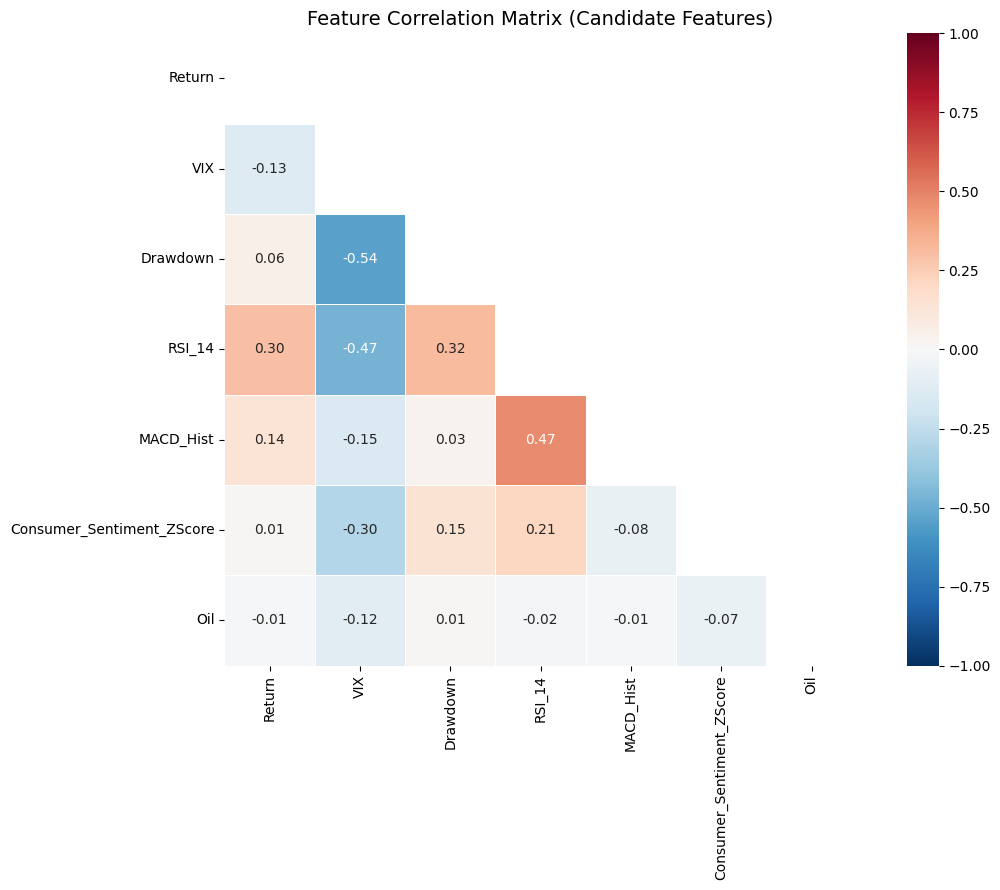

In [399]:
corr_matrix = df_work[candidate_features].corr()

# Plot correlation between defined features 
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Candidate Features)', fontsize=14)
plt.tight_layout()
plt.show()

In [400]:
# Remove highly collinear features
collinearity_threshold = 0.8

# Identify pairs exceeding the threshold
upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > collinearity_threshold:
            high_corr_pairs.append((idx, col, round(val, 3)))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {collinearity_threshold}):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: r = {r}")
else:
    print("No highly correlated pairs found.")

features_to_drop = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in features_to_drop and f2 not in features_to_drop:
        # Drop the feature that appears more in the correlated pairs
        count_f1 = sum(1 for a, b, _ in high_corr_pairs if a == f1 or b == f1)
        count_f2 = sum(1 for a, b, _ in high_corr_pairs if a == f2 or b == f2)
        drop = f1 if count_f1 >= count_f2 else f2
        features_to_drop.add(drop)

selected_features = [f for f in candidate_features if f not in features_to_drop]

print(f"\nFeatures removed due to collinearity: {sorted(features_to_drop)}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

No highly correlated pairs found.

Features removed due to collinearity: []
Selected features (7): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Oil']


### Standardization

Standardize the selected features to zero mean and unit variance so that variables on different scales (e.g., index prices vs. percentages) do not distort the GMM clustering.

In [401]:
scaler = StandardScaler()
X_raw = df_work[selected_features].values
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X.shape}")
print(f"Post-standardization means:  {X.mean(axis=0).round(6)}")
print(f"Post-standardization stds:   {X.std(axis=0).round(6)}")

Feature matrix shape: (8045, 7)
Post-standardization means:  [ 0.  0. -0. -0.  0.  0.  0.]
Post-standardization stds:   [1. 1. 1. 1. 1. 1. 1.]


---
## GMM Model Configuration & Training

We train a **Gaussian Mixture Model** with:
- **K = 2** components (forced binary Bull/Bear segmentation — BIC/AIC bypassed)
- **Full covariance** matrices (captures correlations between features within each cluster)
- **EM algorithm** to maximize the log-likelihood
- **Soft (probabilistic) assignment** — each observation gets a posterior probability of belonging to each regime

In [402]:
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    max_iter=1000,
    n_init=10,          
    random_state=42,
    tol=1e-6
)

gmm.fit(X)

print(f"GMM converged: {gmm.converged_}")
print(f"Number of EM iterations: {gmm.n_iter_}")
print(f"Log-likelihood (lower bound): {gmm.lower_bound_:.4f}")
print(f"BIC: {gmm.bic(X):.2f}  |  AIC: {gmm.aic(X):.2f}")
print(f"\nMixing weights: {gmm.weights_.round(4)}")

GMM converged: True
Number of EM iterations: 30
Log-likelihood (lower bound): -8.5461
BIC: 138144.89  |  AIC: 137648.40

Mixing weights: [0.3036 0.6964]


In [403]:
proba = gmm.predict_proba(X)  
labels = gmm.predict(X)        

print(f"Posterior probability matrix shape: {proba.shape}")
print(f"\nSample posterior probabilities (first 5 observations):")
print(pd.DataFrame(proba[:5], columns=['P(Cluster 0)', 'P(Cluster 1)']).round(4))

# Sample a couple of posteroir distributions
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"\nCluster {u}: {c} observations ({c/len(labels)*100:.1f}%)")

Posterior probability matrix shape: (8045, 2)

Sample posterior probabilities (first 5 observations):
   P(Cluster 0)  P(Cluster 1)
0        0.0088        0.9912
1        0.0104        0.9896
2        0.0084        0.9916
3        0.0059        0.9941
4        0.0063        0.9937

Cluster 0: 2320 observations (28.8%)

Cluster 1: 5725 observations (71.2%)


---
## Regime Interpretation & Labeling

### Cluster Return Profiles

In [404]:
df_work['cluster'] = labels
df_work['prob_cluster_0'] = proba[:, 0]
df_work['prob_cluster_1'] = proba[:, 1]

# Compute return profiles per cluster
trading_days_per_year = 252
risk_free_rate = 0.0  

profile = []
for cluster_id in [0, 1]:
    mask = df_work['cluster'] == cluster_id
    rets = df_work.loc[mask, ret_col]
    
    mean_daily = rets.mean()
    std_daily = rets.std()
    ann_return = mean_daily * trading_days_per_year
    ann_vol = std_daily * np.sqrt(trading_days_per_year)
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else 0.0
    
    mean_vix = df_work.loc[mask, 'VIX'].mean()
    mean_drawdown = df_work.loc[mask, 'Drawdown'].mean()
    
    # Not used atm, if we want to use these add to profile dictionary
    #mean_gdp_yoy = df_work.loc[mask, 'GDP_YoY'].mean() if 'GDP_YoY' in df_work.columns else np.nan
    #mean_unemp = df_work.loc[mask, 'Unemployment'].mean() if 'Unemployment' in df_work.columns else np.nan
    
    profile.append({
        'Cluster': cluster_id,
        'Count': mask.sum(),
        'Ann. Return': ann_return,
        'Ann. Volatility': ann_vol,
        'Sharpe Ratio': sharpe,
        'Mean VIX': mean_vix,
        'Mean Drawdown': mean_drawdown
    })

profile_df = pd.DataFrame(profile).set_index('Cluster')
print("Cluster Return & Risk Profiles:\n")
print(profile_df.round(4).to_string())

Cluster Return & Risk Profiles:

         Count  Ann. Return  Ann. Volatility  Sharpe Ratio  Mean VIX  Mean Drawdown
Cluster                                                                            
0         2320       0.0005           0.3016        0.0016   27.2774        -0.1644
1         5725       0.1451           0.1098        1.3210   16.7393        -0.0895


Check original features in the two assigned clusters, want to see a difference in returns, VIX etc.

In [405]:
means_original = scaler.inverse_transform(gmm.means_)
means_df = pd.DataFrame(means_original, columns=selected_features, index=['Cluster 0', 'Cluster 1'])
print("GMM Component Means (Original Scale):\n")
print(means_df.round(6).to_string())

GMM Component Means (Original Scale):

             Return        VIX  Drawdown     RSI_14  MACD_Hist  Consumer_Sentiment_ZScore        Oil
Cluster 0  0.000001  26.720659 -0.159800  48.438578  -0.349530                  -0.673070  62.170898
Cluster 1  0.000589  16.752058 -0.089917  57.270675   0.149365                   0.312417  53.147364


Now we assign Bull/Bear labels based on annualized returns

In [406]:
if profile_df.loc[0, 'Ann. Return'] > profile_df.loc[1, 'Ann. Return']:
    bull_cluster = 0
    bear_cluster = 1
else:
    bull_cluster = 1
    bear_cluster = 0

print(f"Bull Market  -> Cluster {bull_cluster}")
print(f"  Ann. Return:    {profile_df.loc[bull_cluster, 'Ann. Return']:.4f}")
print(f"  Ann. Volatility:{profile_df.loc[bull_cluster, 'Ann. Volatility']:.4f}")
print(f"  Sharpe Ratio:   {profile_df.loc[bull_cluster, 'Sharpe Ratio']:.4f}")
print(f"  Mean VIX:       {profile_df.loc[bull_cluster, 'Mean VIX']:.2f}")
print()
print(f"Bear Market  -> Cluster {bear_cluster}")
print(f"  Ann. Return:    {profile_df.loc[bear_cluster, 'Ann. Return']:.4f}")
print(f"  Ann. Volatility:{profile_df.loc[bear_cluster, 'Ann. Volatility']:.4f}")
print(f"  Sharpe Ratio:   {profile_df.loc[bear_cluster, 'Sharpe Ratio']:.4f}")
print(f"  Mean VIX:       {profile_df.loc[bear_cluster, 'Mean VIX']:.2f}")

df_work['prob_bull'] = proba[:, bull_cluster]
df_work['prob_bear'] = proba[:, bear_cluster]
# Smooth the posterior probability with a 21-day rolling mean before thresholding
df_work['prob_bull_smooth'] = df_work['prob_bull'].rolling(120, min_periods=1, center=True).mean()
df_work['regime'] = np.where(df_work['prob_bull_smooth'] > 0.5, 'bull', 'bear')

Bull Market  -> Cluster 1
  Ann. Return:    0.1451
  Ann. Volatility:0.1098
  Sharpe Ratio:   1.3210
  Mean VIX:       16.74

Bear Market  -> Cluster 0
  Ann. Return:    0.0005
  Ann. Volatility:0.3016
  Sharpe Ratio:   0.0016
  Mean VIX:       27.28


Visualization of Regime Segmentation over Time-Series

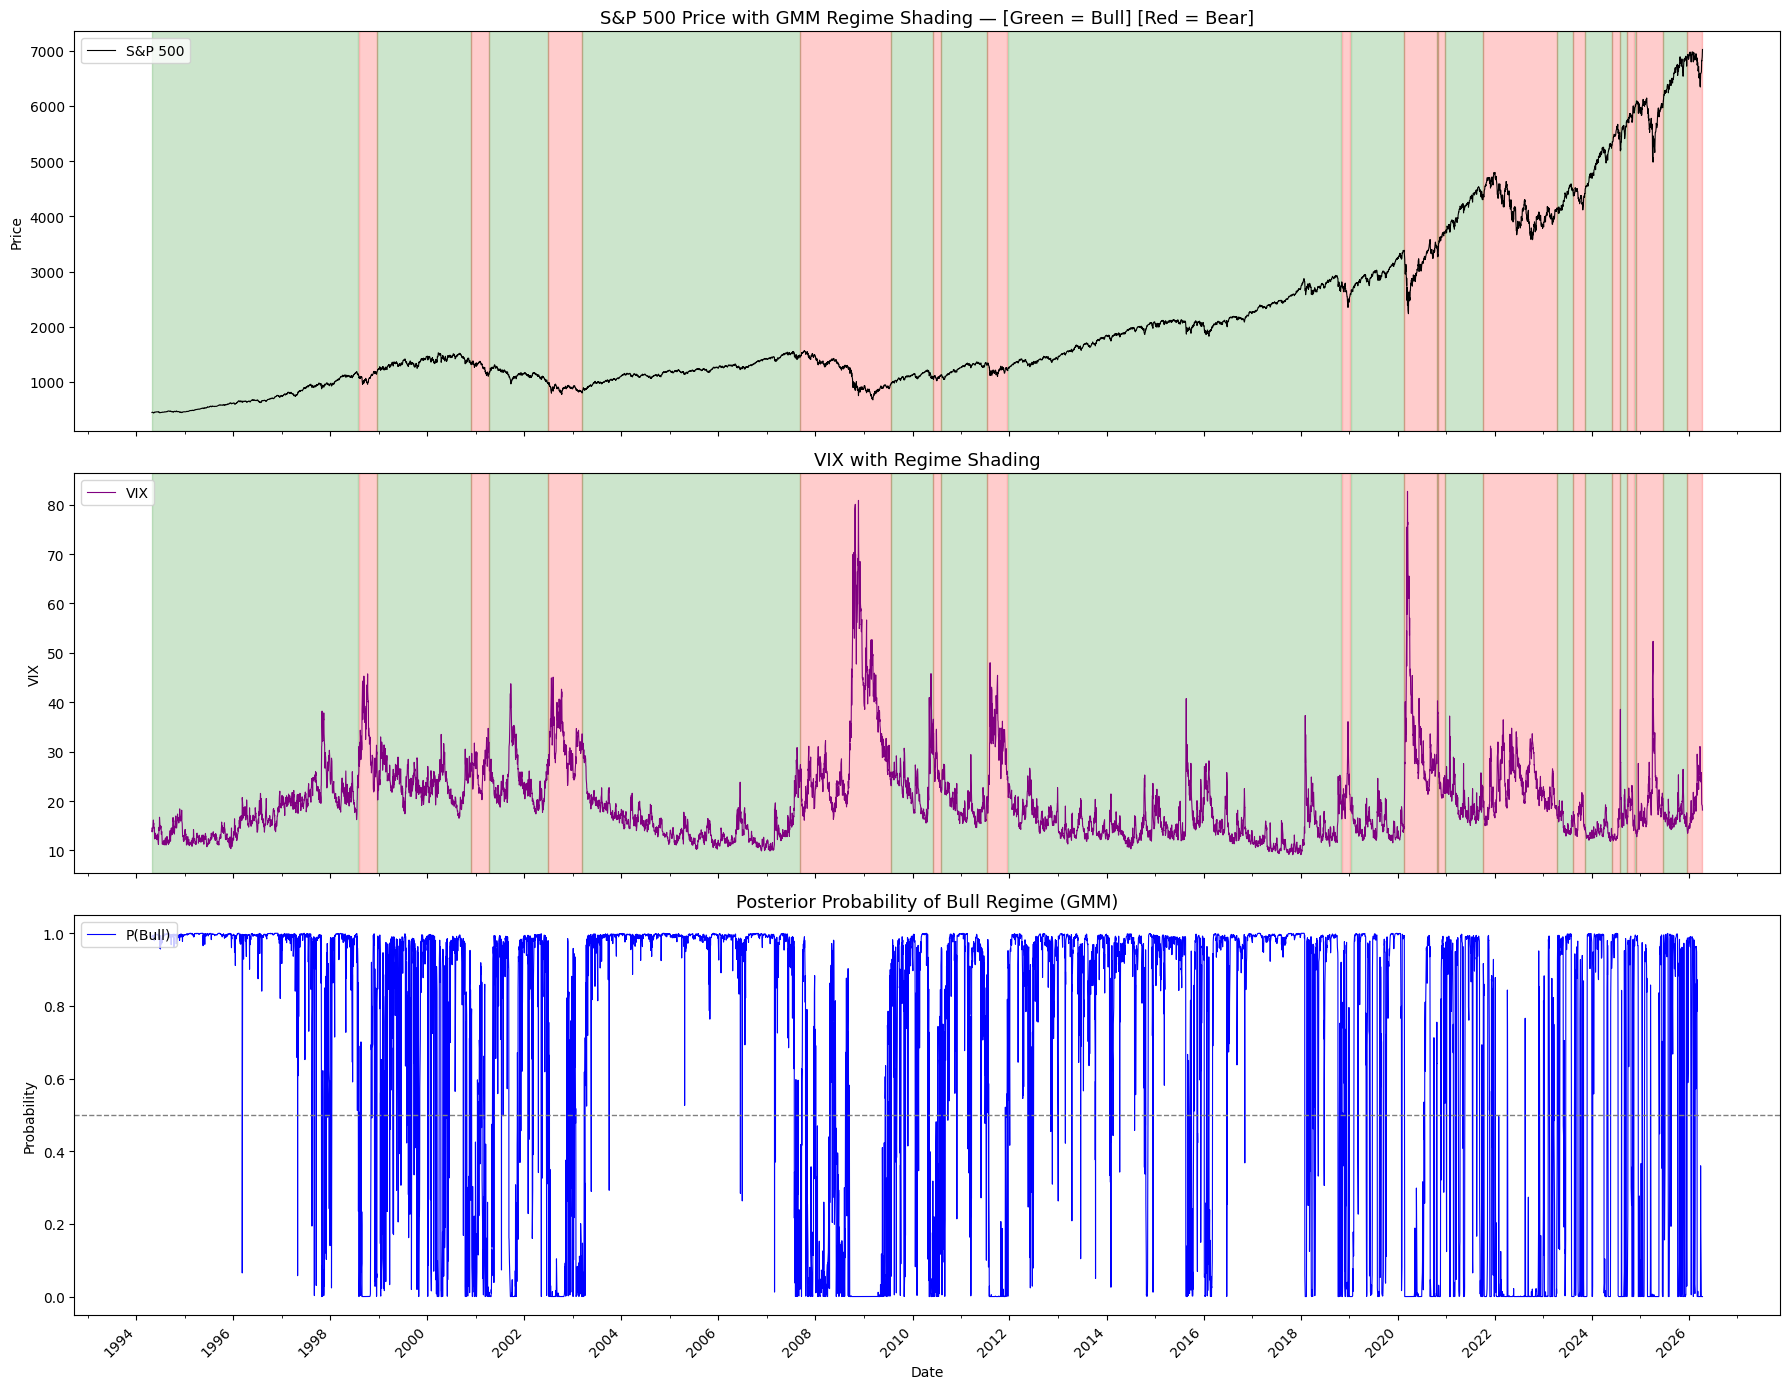

In [407]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

ax1.plot(df_work['Date'], df_work[price_col], color='black', linewidth=0.8, label='S&P 500')
ax1.set_title('S&P 500 Price with GMM Regime Shading — [Green = Bull] [Red = Bear]', fontsize=13)
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

df_work['regime_change'] = (df_work['regime'] != df_work['regime'].shift(1)).cumsum()
for _, group in df_work.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

# --- Plot 2: VIX with regime shading ---
ax2.plot(df_work['Date'], df_work['VIX'], color='purple', linewidth=0.8, label='VIX')
ax2.set_title('VIX with Regime Shading', fontsize=13)
ax2.set_ylabel('VIX')
ax2.legend(loc='upper left')

for _, group in df_work.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax2.axvspan(start_date, end_date, color=color, alpha=0.2)

# --- Plot 3: Posterior probability of Bull regime ---
ax3.plot(df_work['Date'], df_work['prob_bull'], color='blue', linewidth=0.8, label='P(Bull)')
ax3.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_title('Posterior Probability of Bull Regime (GMM)', fontsize=13)
ax3.set_ylabel('Probability')
ax3.set_ylim(-0.05, 1.05)
ax3.legend(loc='upper left')

ax3.xaxis.set_major_locator(mdates.YearLocator(2))
ax3.xaxis.set_minor_locator(mdates.YearLocator(1))
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.set_xlabel('Date')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

df_work = df_work.drop(columns=['regime_change'])

### Historical Validation

We validate the regime labels against well-known market events:
- **Dot-Com Crash**: ~Mar 2000 – Oct 2002
- **Global Financial Crisis (GFC)**: ~Oct 2007 – Mar 2009
- **COVID-19 Crash**: ~Feb 2020 – Mar 2020
- **Expansionary Periods**: 2003–2007, 2010–2019

In [408]:
events = {
    'Dot-Com Crash':      ('2001-03-01', '2002-10-31'),
    'GFC':                ('2007-10-01', '2009-03-31'),
    'COVID-19 Crash':     ('2020-02-01', '2020-03-31'),
    'Post-GFC Recovery':  ('2010-01-01', '2019-12-31'),
    'Mid-2000s Bull':     ('2003-04-01', '2007-09-30'),
}

print("Historical Event Validation")
print("=" * 75)
for event_name, (start, end) in events.items():
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    if mask.sum() == 0:
        print(f"\n{event_name} ({start} to {end}): No data available")
        continue
    
    event_data = df_work.loc[mask]
    bull_pct = (event_data['regime'] == 'bull').mean() * 100
    bear_pct = (event_data['regime'] == 'bear').mean() * 100
    avg_prob_bull = event_data['prob_bull'].mean()
    avg_ret = event_data[ret_col].mean() * trading_days_per_year
    
    print(f"\n{event_name} ({start} to {end}):")
    print(f"  Days: {mask.sum()} | Bull: {bull_pct:.1f}% | Bear: {bear_pct:.1f}%")
    print(f"  Avg P(Bull): {avg_prob_bull:.3f} | Ann. Return: {avg_ret:.4f}")

Historical Event Validation

Dot-Com Crash (2001-03-01 to 2002-10-31):
  Days: 419 | Bull: 71.8% | Bear: 28.2%
  Avg P(Bull): 0.548 | Ann. Return: -0.1726

GFC (2007-10-01 to 2009-03-31):
  Days: 378 | Bull: 0.0% | Bear: 100.0%
  Avg P(Bull): 0.188 | Ann. Return: -0.3590

COVID-19 Crash (2020-02-01 to 2020-03-31):
  Days: 41 | Bull: 26.8% | Bear: 73.2%
  Avg P(Bull): 0.299 | Ann. Return: -1.1187

Post-GFC Recovery (2010-01-01 to 2019-12-31):
  Days: 2516 | Bull: 92.2% | Bear: 7.8%
  Avg P(Bull): 0.795 | Ann. Return: 0.1175

Mid-2000s Bull (2003-04-01 to 2007-09-30):
  Days: 1133 | Bull: 98.5% | Bear: 1.5%
  Avg P(Bull): 0.949 | Ann. Return: 0.1378


### Regime Transition Analysis

In [409]:
regimes = df_work['regime'].values
transitions = {'bull->bull': 0, 'bull->bear': 0, 'bear->bull': 0, 'bear->bear': 0}

for i in range(len(regimes) - 1):
    key = f"{regimes[i]}->{regimes[i+1]}"
    transitions[key] += 1

# Normalize to probabilities
bull_total = transitions['bull->bull'] + transitions['bull->bear']
bear_total = transitions['bear->bull'] + transitions['bear->bear']

trans_matrix = pd.DataFrame([
    [transitions['bull->bull'] / bull_total, transitions['bull->bear'] / bull_total],
    [transitions['bear->bull'] / bear_total, transitions['bear->bear'] / bear_total]
], index=['From Bull', 'From Bear'], columns=['To Bull', 'To Bear'])

print("Empirical Regime Transition Matrix:\n")
print(trans_matrix.round(4).to_string())

# Count regime switches
switches = (df_work['regime'] != df_work['regime'].shift(1)).sum() - 1
print(f"\nTotal regime switches: {switches}")
print(f"Average regime duration: {len(df_work) / (switches + 1):.1f} trading days")

Empirical Regime Transition Matrix:

           To Bull  To Bear
From Bull   0.9975   0.0025
From Bear   0.0071   0.9929

Total regime switches: 29
Average regime duration: 268.2 trading days


---
## Diagnostic Validation

We now critically evaluate the GMM regime labels across several dimensions:
1. **Cluster profile sanity** — Do the return/risk statistics align with intuitive Bull vs. Bear definitions?
2. **Historical alignment** — Are known crashes flagged as Bear and expansions as Bull?
3. **Regime stability** — Is the switching frequency realistic, or is the model "chattering"?
4. **Temporal coherence** — Does the large post-2020 regime block make economic sense?
5. **Feature-level diagnostics** — Which features drive the separation?

In [410]:
print("=" * 80)
print("5.1  CLUSTER PROFILE SANITY CHECK")
print("=" * 80)

bull_ret  = profile_df.loc[bull_cluster, 'Ann. Return']
bear_ret  = profile_df.loc[bear_cluster, 'Ann. Return']
bull_vol  = profile_df.loc[bull_cluster, 'Ann. Volatility']
bear_vol  = profile_df.loc[bear_cluster, 'Ann. Volatility']
bull_vix  = profile_df.loc[bull_cluster, 'Mean VIX']
bear_vix  = profile_df.loc[bear_cluster, 'Mean VIX']

checks = {
    'Bull return > Bear return':      bull_ret > bear_ret,
    'Bull vol < Bear vol':            bull_vol < bear_vol,
    'Bull VIX < Bear VIX':            bull_vix < bear_vix,
    'Bear return is negative':        bear_ret < 0,
    'Bull Sharpe > 0.5':              profile_df.loc[bull_cluster, 'Sharpe Ratio'] > 0.5,
    'Bear Sharpe < 0.3':              profile_df.loc[bear_cluster, 'Sharpe Ratio'] < 0.3,
}

for desc, passed in checks.items():
    status = "PASS" if passed else "WARN"
    print(f"  [{status}]  {desc}")

5.1  CLUSTER PROFILE SANITY CHECK
  [PASS]  Bull return > Bear return
  [PASS]  Bull vol < Bear vol
  [PASS]  Bull VIX < Bear VIX
  [WARN]  Bear return is negative
  [PASS]  Bull Sharpe > 0.5
  [PASS]  Bear Sharpe < 0.3


In [411]:
print("=" * 80)
print("5.3  REGIME STABILITY DIAGNOSTIC")
print("=" * 80)

# Compute regime durations
regime_runs = []
current_regime = regimes[0]
run_length = 1
for i in range(1, len(regimes)):
    if regimes[i] == current_regime:
        run_length += 1
    else:
        regime_runs.append((current_regime, run_length))
        current_regime = regimes[i]
        run_length = 1
regime_runs.append((current_regime, run_length))

run_df = pd.DataFrame(regime_runs, columns=['regime', 'duration_days'])

print(f"\n  Total regime episodes: {len(run_df)}")
print(f"  Total switches: {switches}")
print(f"  Avg duration: {run_df['duration_days'].mean():.1f} trading days ({run_df['duration_days'].mean()/21:.1f} months)")
print(f"  Median duration: {run_df['duration_days'].median():.0f} trading days")
print(f"  Max duration: {run_df['duration_days'].max()} trading days")
print(f"  Min duration: {run_df['duration_days'].min()} trading days")

# Duration distribution by regime
for r in ['bull', 'bear']:
    sub = run_df[run_df['regime'] == r]
    print(f"\n  {r.upper()} episodes: {len(sub)}")
    print(f"    Mean duration: {sub['duration_days'].mean():.1f} days | Median: {sub['duration_days'].median():.0f} days")

# short episodes
short_episodes = (run_df['duration_days'] < 5).sum()
very_short = (run_df['duration_days'] == 1).sum()
print(f"\n  Episodes < 5 days:  {short_episodes} ({short_episodes/len(run_df)*100:.1f}%)")
print(f"  Episodes = 1 day:   {very_short} ({very_short/len(run_df)*100:.1f}%)")

5.3  REGIME STABILITY DIAGNOSTIC

  Total regime episodes: 30
  Total switches: 29
  Avg duration: 268.2 trading days (12.8 months)
  Median duration: 132 trading days
  Max duration: 1732 trading days
  Min duration: 7 trading days

  BULL episodes: 15
    Mean duration: 404.0 days | Median: 217 days

  BEAR episodes: 15
    Mean duration: 132.3 days | Median: 93 days

  Episodes < 5 days:  0 (0.0%)
  Episodes = 1 day:   0 (0.0%)


We can see that number of regime switches is generally quite high, this is a fundamental issue with the GMM, due to the fact that it is not time-dependent like the HMM.

In [412]:
print("=" * 80)
print("FEATURE CONTRIBUTION TO REGIME SEPARATION")
print("=" * 80)

means_std = pd.DataFrame(gmm.means_, columns=selected_features, index=['Bear (Cluster 0)', 'Bull (Cluster 1)'])
separation = (means_std.loc['Bull (Cluster 1)'] - means_std.loc['Bear (Cluster 0)']).abs()
separation = separation.sort_values(ascending=False)

print("\nAbsolute separation between cluster means (standardized space):")
print("  (Larger = more influential in distinguishing regimes)\n")
for feat, val in separation.items():
    bar = "█" * int(val * 15)
    print(f"  {feat:25s}  {val:.3f}  {bar}")

print(f"\n  Feature-level comparison (original scale):")
for feat in separation.index:
    bull_val = means_df.loc['Cluster 1' if bull_cluster == 1 else 'Cluster 0', feat]
    bear_val = means_df.loc['Cluster 0' if bear_cluster == 0 else 'Cluster 1', feat]
    print(f"    {feat:25s}  Bull: {bull_val:+10.4f}  |  Bear: {bear_val:+10.4f}")

FEATURE CONTRIBUTION TO REGIME SEPARATION

Absolute separation between cluster means (standardized space):
  (Larger = more influential in distinguishing regimes)

  VIX                        1.243  ██████████████████
  RSI_14                     0.775  ███████████
  Consumer_Sentiment_ZScore  0.747  ███████████
  Drawdown                   0.566  ████████
  Oil                        0.317  ████
  MACD_Hist                  0.061  
  Return                     0.050  

  Feature-level comparison (original scale):
    VIX                        Bull:   +16.7521  |  Bear:   +26.7207
    RSI_14                     Bull:   +57.2707  |  Bear:   +48.4386
    Consumer_Sentiment_ZScore  Bull:    +0.3124  |  Bear:    -0.6731
    Drawdown                   Bull:    -0.0899  |  Bear:    -0.1598
    Oil                        Bull:   +53.1474  |  Bear:   +62.1709
    MACD_Hist                  Bull:    +0.1494  |  Bear:    -0.3495
    Return                     Bull:    +0.0006  |  Bear:    +0.0

In [413]:
# Merge regime labels back to the full dataset
if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

# Keep only essential columns from df_work for merging
merge_cols = ['Date', 'regime', 'prob_bull', 'prob_bear']
df_out = df.merge(df_work[merge_cols], on='Date', how='left')

# Fill any unmatched rows with the nearest regime
first_regime = df_work['regime'].iloc[0]
df_out['regime'] = df_out['regime'].fillna(first_regime)
df_out['prob_bull'] = df_out['prob_bull'].fillna(0.5)
df_out['prob_bear'] = df_out['prob_bear'].fillna(0.5)

# Validation
missing_regimes = df_out['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

# Save
output_csv = r'../../../data/multivariate_gmm_labeled_dataset.csv'
df_out.to_csv(output_csv, index=False)
print(f"\nDataset saved to {output_csv}")
print(f"Output shape: {df_out.shape}")
print(f"\nFinal regime counts:")
print(df_out['regime'].value_counts())

Validation passed: No missing values in 'regime' column.

Dataset saved to ../../../data/multivariate_gmm_labeled_dataset.csv
Output shape: (8107, 31)

Final regime counts:
regime
bull    6122
bear    1985
Name: count, dtype: int64


In [414]:
# =============================================================================
# PILLAR 2: REAL DATA VALIDATION
# =============================================================================

from scipy import stats

# --- 1. NBER Recession Dates (official US recession periods) ---
nber_periods = [
    ('1994-01-27', '2001-02-28', 'bull', '1990s Expansion'),
    ('2001-03-01', '2001-11-30', 'bear', '2001 Recession (Dot-Com)'),
    ('2001-12-01', '2007-11-30', 'bull', 'Early 2000s Expansion'),
    ('2007-12-01', '2009-06-30', 'bear', 'Great Recession (GFC)'),
    ('2009-07-01', '2020-01-31', 'bull', 'Post-GFC Expansion'),
    ('2020-02-01', '2020-04-30', 'bear', 'COVID-19 Recession'),
    ('2020-05-01', '2025-12-31', 'bull', 'Post-COVID Recovery'),
]

# Merge regime predictions back to original df for validation
df_full = df.copy()
df_full = df_full.merge(df_work[['Date', 'regime', 'prob_bull', 'prob_bear']], on='Date', how='left')
first_regime = df_work['regime'].iloc[0]
df_full['regime'] = df_full['regime'].fillna(first_regime)
df_work = df_full  # Now df_work has all dates with regimes filled

# Create NBER ground truth column
df_work['nber_regime'] = 'bull'  # default
for start, end, regime, _ in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    df_work.loc[mask, 'nber_regime'] = regime

print("NBER Business Cycle Ground Truth")
print("=" * 75)
print(f"{'Period':<35s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for start, end, expected, name in nber_periods:
    mask = (df_work['Date'] >= start) & (df_work['Date'] <= end)
    if mask.sum() == 0:
        print(f"  {name:<35s}  {'—':>30s} No data in range")
        continue
    period_data = df_work.loc[mask]
    match_pct = (period_data['regime'] == expected).mean() * 100
    n_days = mask.sum()
    print(f"  {name:<35s} {expected:<8s} {n_days:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
nber_acc = (df_work['regime'] == df_work['nber_regime']).mean()
nber_bear_mask = df_work['nber_regime'] == 'bear'
nber_bear_recall = (df_work.loc[nber_bear_mask, 'regime'] == 'bear').mean() if nber_bear_mask.sum() > 0 else 0
pred_bear_mask = df_work['regime'] == 'bear'
nber_bear_precision = (df_work.loc[pred_bear_mask, 'nber_regime'] == 'bear').mean() if pred_bear_mask.sum() > 0 else 0

from sklearn.metrics import classification_report, confusion_matrix

# --- NBER Aggregated ---
print(f"\nAggregated (vs NBER):")
print(classification_report(df_work['nber_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['nber_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))


# --- 2. 20% Drawdown Rule ---
peak = df_work[price_col].cummax()
drawdown_from_peak = (df_work[price_col] - peak) / peak

in_bear = False
df_work['drawdown_regime'] = 'bull'
for i in range(len(df_work)):
    if drawdown_from_peak.iloc[i] <= -0.20:
        in_bear = True
    elif in_bear and drawdown_from_peak.iloc[i] >= -0.05:
        in_bear = False
    if in_bear:
        df_work.loc[df_work.index[i], 'drawdown_regime'] = 'bear'

# Identify contiguous drawdown bear periods and label them
dd_changes = (df_work['drawdown_regime'] != df_work['drawdown_regime'].shift(1)).cumsum()
dd_bear_num = 0

print("\n\n20% Drawdown Rule Ground Truth")
print("=" * 75)
print(f"{'Period':<40s} {'Expected':<8s} {'Days':>5s} {'Match%':>8s}")
print("-" * 75)

for _, group in df_work.groupby(dd_changes):
    r = group['drawdown_regime'].iloc[0]
    s = group['Date'].iloc[0].strftime('%Y-%m-%d')
    e = group['Date'].iloc[-1].strftime('%Y-%m-%d')
    n = len(group)
    match_pct = (group['regime'] == r).mean() * 100

    if r == 'bear':
        dd_bear_num += 1
        label = f"Bear {dd_bear_num} ({s} to {e})"
    else:
        label = f"Bull ({s} to {e})"

    # Only print bear periods and bulls longer than 250 days to keep output readable
    if r == 'bear' or n > 250:
        print(f"  {label:<40s} {r:<8s} {n:>5d} {match_pct:>7.1f}%")

# Aggregated stats
print(f"\n{'Aggregated':}")
dd_acc = (df_work['regime'] == df_work['drawdown_regime']).mean()
dd_bear_mask = df_work['drawdown_regime'] == 'bear'
dd_bear_recall = (df_work.loc[dd_bear_mask, 'regime'] == 'bear').mean() if dd_bear_mask.sum() > 0 else 0
dd_pred_bear_mask = df_work['regime'] == 'bear'
dd_bear_precision = (df_work.loc[dd_pred_bear_mask, 'drawdown_regime'] == 'bear').mean() if dd_pred_bear_mask.sum() > 0 else 0

# --- Drawdown Aggregated ---
print(f"\nAggregated (vs 20% Drawdown Rule):")
print(classification_report(df_work['drawdown_regime'], df_work['regime'],
                            target_names=['bear', 'bull']))
cm = confusion_matrix(df_work['drawdown_regime'], df_work['regime'], labels=['bear', 'bull'])
print(pd.DataFrame(cm, index=['True Bear', 'True Bull'], columns=['Pred Bear', 'Pred Bull']))

NBER Business Cycle Ground Truth
Period                              Expected  Days   Match%
---------------------------------------------------------------------------
  1990s Expansion                     bull      1789    90.9%
  2001 Recession (Dot-Com)            bear       188    14.9%
  Early 2000s Expansion               bull      1510    84.1%
  Great Recession (GFC)               bear       397   100.0%
  Post-GFC Expansion                  bull      2665    92.0%
  COVID-19 Recession                  bear        62    82.3%
  Post-COVID Recovery                 bull      1425    42.3%

Aggregated

Aggregated (vs NBER):
              precision    recall  f1-score   support

        bear       0.24      0.74      0.36       647
        bull       0.97      0.80      0.88      7460

    accuracy                           0.79      8107
   macro avg       0.61      0.77      0.62      8107
weighted avg       0.91      0.79      0.84      8107

           Pred Bear  Pred Bull
Tru

In [419]:
# =============================================================================
# STATISTICAL SIGNIFICANCE OF REGIME SEPARATION
# =============================================================================

print("Statistical Significance of GMM Regime Labels")
print("=" * 70)
print("H0: No difference between bull and bear regime distributions")
print("Test: Welch's t-test (unequal variances)\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

results = []
for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()

    t_stat, p_val = stats.ttest_ind(bull_vals, bear_vals, equal_var=False)

    results.append({
        'Feature': name,
        'Bull Mean': bull_vals.mean(),
        'Bear Mean': bear_vals.mean(),
        'Difference': bull_vals.mean() - bear_vals.mean(),
        't-statistic': t_stat,
        'p-value': p_val,
        'Significant (p<0.01)': 'Yes' if p_val < 0.01 else 'No',
    })

    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Also test volatility (std of returns in rolling windows)
bull_vol = df_work.loc[bull_mask, ret_col].rolling(21).std().dropna()
bear_vol = df_work.loc[bear_mask, ret_col].rolling(21).std().dropna()
t_stat, p_val = stats.ttest_ind(bull_vol, bear_vol, equal_var=False)
print(f"  {'21d Volatility':15s} | Bull: {bull_vol.mean():+.6f} | Bear: {bear_vol.mean():+.6f} | "
      f"t={t_stat:+.2f} | p={p_val:.2e} | {'***' if p_val < 0.01 else 'n.s.'}")

# Kolmogorov-Smirnov test on return distributions
print("\nKolmogorov-Smirnov D Statistics (Distributional Separation)")
print("=" * 70)
print("Interpretation: D = max CDF gap between bull and bear (0 = identical, 1 = no overlap)\n")

for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()
    
    ks_stat, _ = stats.ks_2samp(bull_vals, bear_vals)
    print(f"  {name:15s} | D={ks_stat:.4f}")

Statistical Significance of GMM Regime Labels
H0: No difference between bull and bear regime distributions
Test: Welch's t-test (unequal variances)

  Daily Return    | Bull: +0.000585 | Bear: -0.000163 | t=+1.78 | p=7.57e-02 | n.s.
  VIX             | Bull: +17.227914 | Bear: +27.491884 | t=-43.02 | p=4.36e-297 | ***
  Drawdown        | Bull: -0.090146 | Bear: -0.173649 | t=+23.31 | p=1.31e-109 | ***
  RSI_14          | Bull: +56.114314 | Bear: +49.564034 | t=+22.78 | p=7.52e-107 | ***
  MACD_Hist       | Bull: -0.064265 | Bear: +0.176719 | t=-0.76 | p=4.50e-01 | n.s.
  21d Volatility  | Bull: +0.008135 | Bear: +0.015848 | t=-36.80 | p=5.79e-230 | ***

Kolmogorov-Smirnov D Statistics (Distributional Separation)
Interpretation: D = max CDF gap between bull and bear (0 = identical, 1 = no overlap)

  Daily Return    | D=0.1404
  VIX             | D=0.5225
  Drawdown        | D=0.3294
  RSI_14          | D=0.2396
  MACD_Hist       | D=0.2018


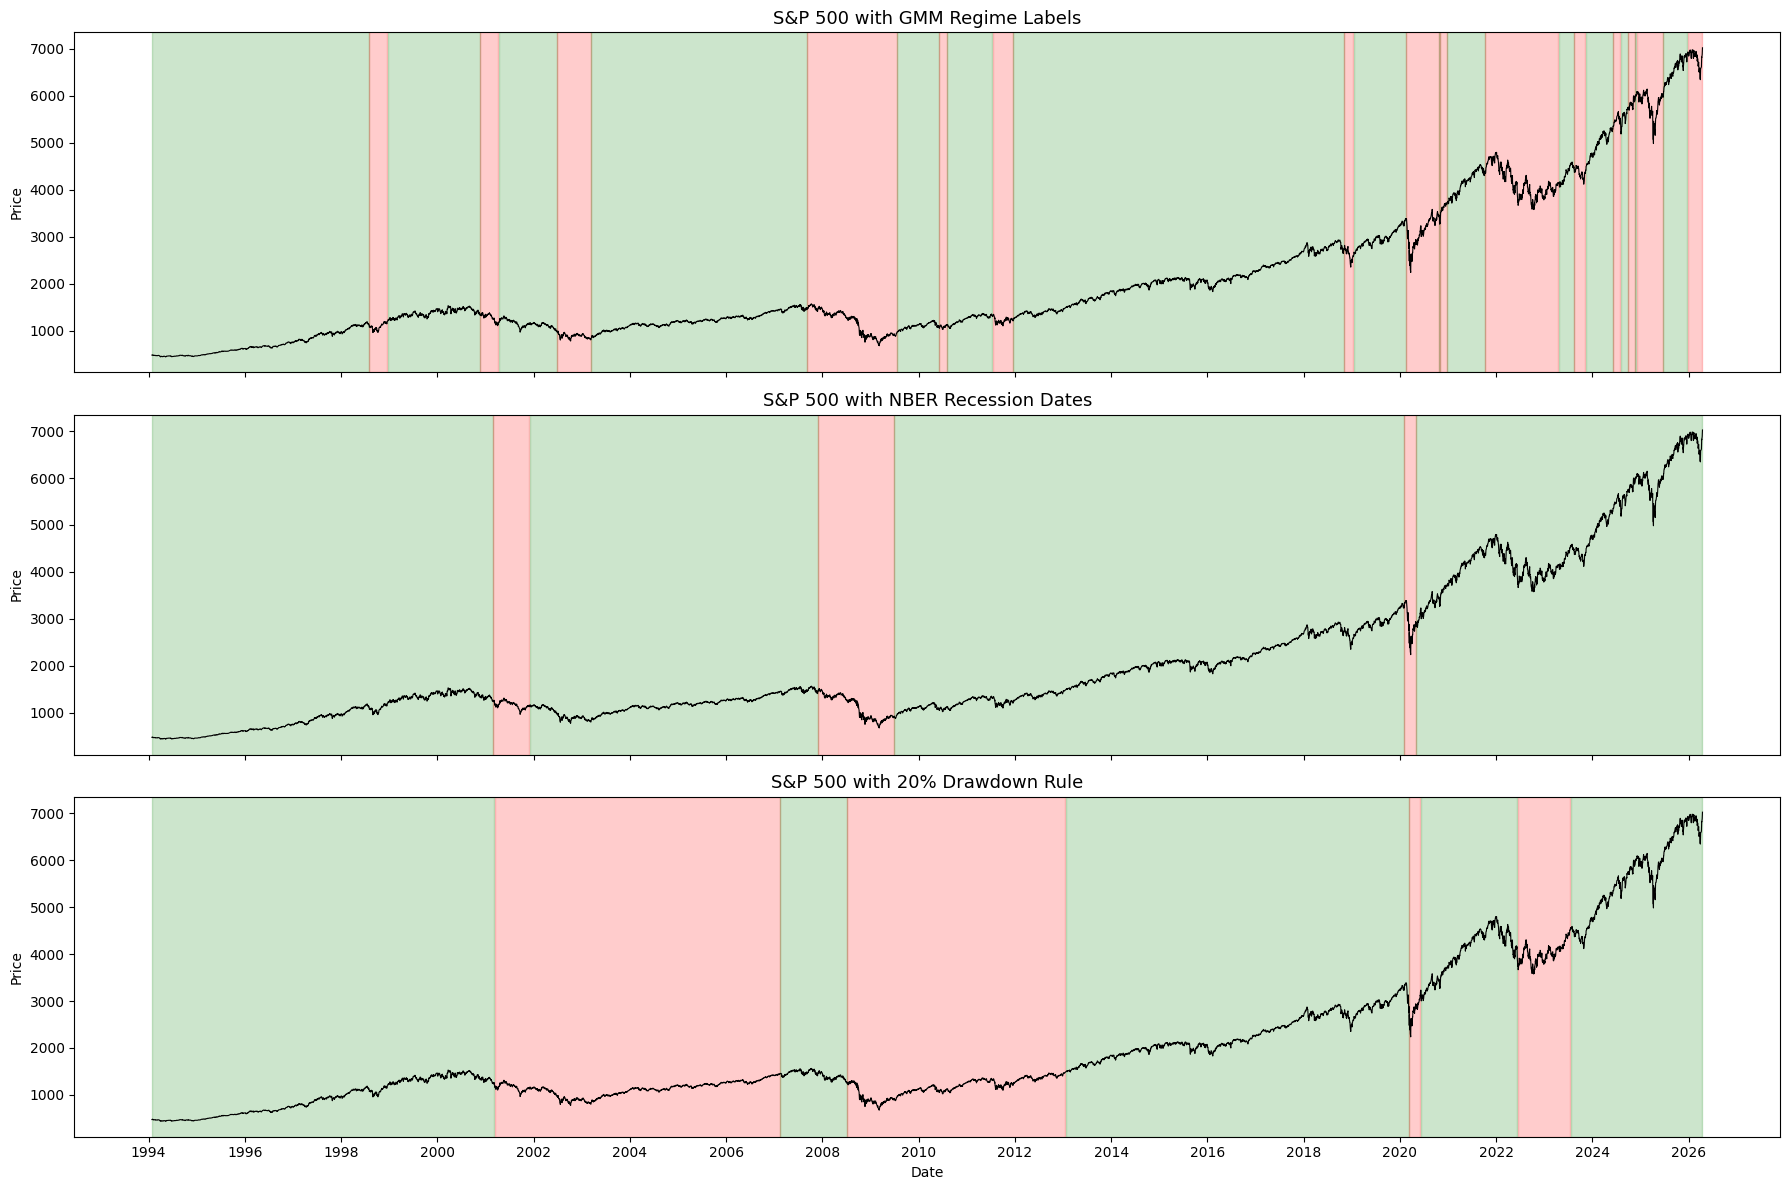

In [416]:
# =============================================================================
# VISUAL COMPARISON: GMM vs NBER vs 20% DRAWDOWN
# =============================================================================

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)

for ax, (label, regime_col) in zip(axes, [
    ('GMM Regime Labels', 'regime'),
    ('NBER Recession Dates', 'nber_regime'),
    ('20% Drawdown Rule', 'drawdown_regime'),
]):
    ax.plot(df_work['Date'], df_work[price_col], color='black', linewidth=0.8)
    ax.set_title(f'S&P 500 with {label}', fontsize=13)
    ax.set_ylabel('Price')

    changes = (df_work[regime_col] != df_work[regime_col].shift(1)).cumsum()
    for _, group in df_work.groupby(changes):
        s = group['Date'].iloc[0]
        e = group['Date'].iloc[-1]
        r = group[regime_col].iloc[0]
        ax.axvspan(s, e, color='green' if r == 'bull' else 'red', alpha=0.2)

axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.show()

In [417]:
def cohens_d(group_a, group_b):
    """Compute Cohen's d (pooled std)."""
    na, nb = len(group_a), len(group_b)
    var_a, var_b = group_a.var(), group_b.var()
    pooled_std = np.sqrt(((na - 1) * var_a + (nb - 1) * var_b) / (na + nb - 2))
    return (group_a.mean() - group_b.mean()) / pooled_std

print("Regime Separation: Effect Sizes (Cohen's d)")
print("=" * 70)
print("Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,")
print("                0.5-0.8 medium, > 0.8 large\n")

bull_mask = df_work['regime'] == 'bull'
bear_mask = df_work['regime'] == 'bear'

test_features = {
    'Daily Return':     ret_col,
    'VIX':              'VIX',
    'Drawdown':         'Drawdown',
    'RSI_14':           'RSI_14',
    'MACD_Hist':        'MACD_Hist',
}

for name, col in test_features.items():
    bull_vals = df_work.loc[bull_mask, col].dropna()
    bear_vals = df_work.loc[bear_mask, col].dropna()
    
    d = cohens_d(bull_vals, bear_vals)
    
    if abs(d) >= 0.8:
        magnitude = 'LARGE'
    elif abs(d) >= 0.5:
        magnitude = 'MEDIUM'
    elif abs(d) >= 0.2:
        magnitude = 'SMALL'
    else:
        magnitude = 'NEGLIGIBLE'
    
    print(f"  {name:15s} | Bull: {bull_vals.mean():+.6f} | Bear: {bear_vals.mean():+.6f} | "
          f"d={d:+.3f} | {magnitude}")

Regime Separation: Effect Sizes (Cohen's d)
Interpretation: |d| < 0.2 negligible, 0.2-0.5 small,
                0.5-0.8 medium, > 0.8 large

  Daily Return    | Bull: +0.000585 | Bear: -0.000163 | d=+0.064 | NEGLIGIBLE
  VIX             | Bull: +17.227914 | Bear: +27.491884 | d=-1.537 | LARGE
  Drawdown        | Bull: -0.090146 | Bear: -0.173649 | d=+0.708 | MEDIUM
  RSI_14          | Bull: +56.114314 | Bear: +49.564034 | d=+0.592 | MEDIUM
  MACD_Hist       | Bull: -0.064265 | Bear: +0.176719 | d=-0.029 | NEGLIGIBLE


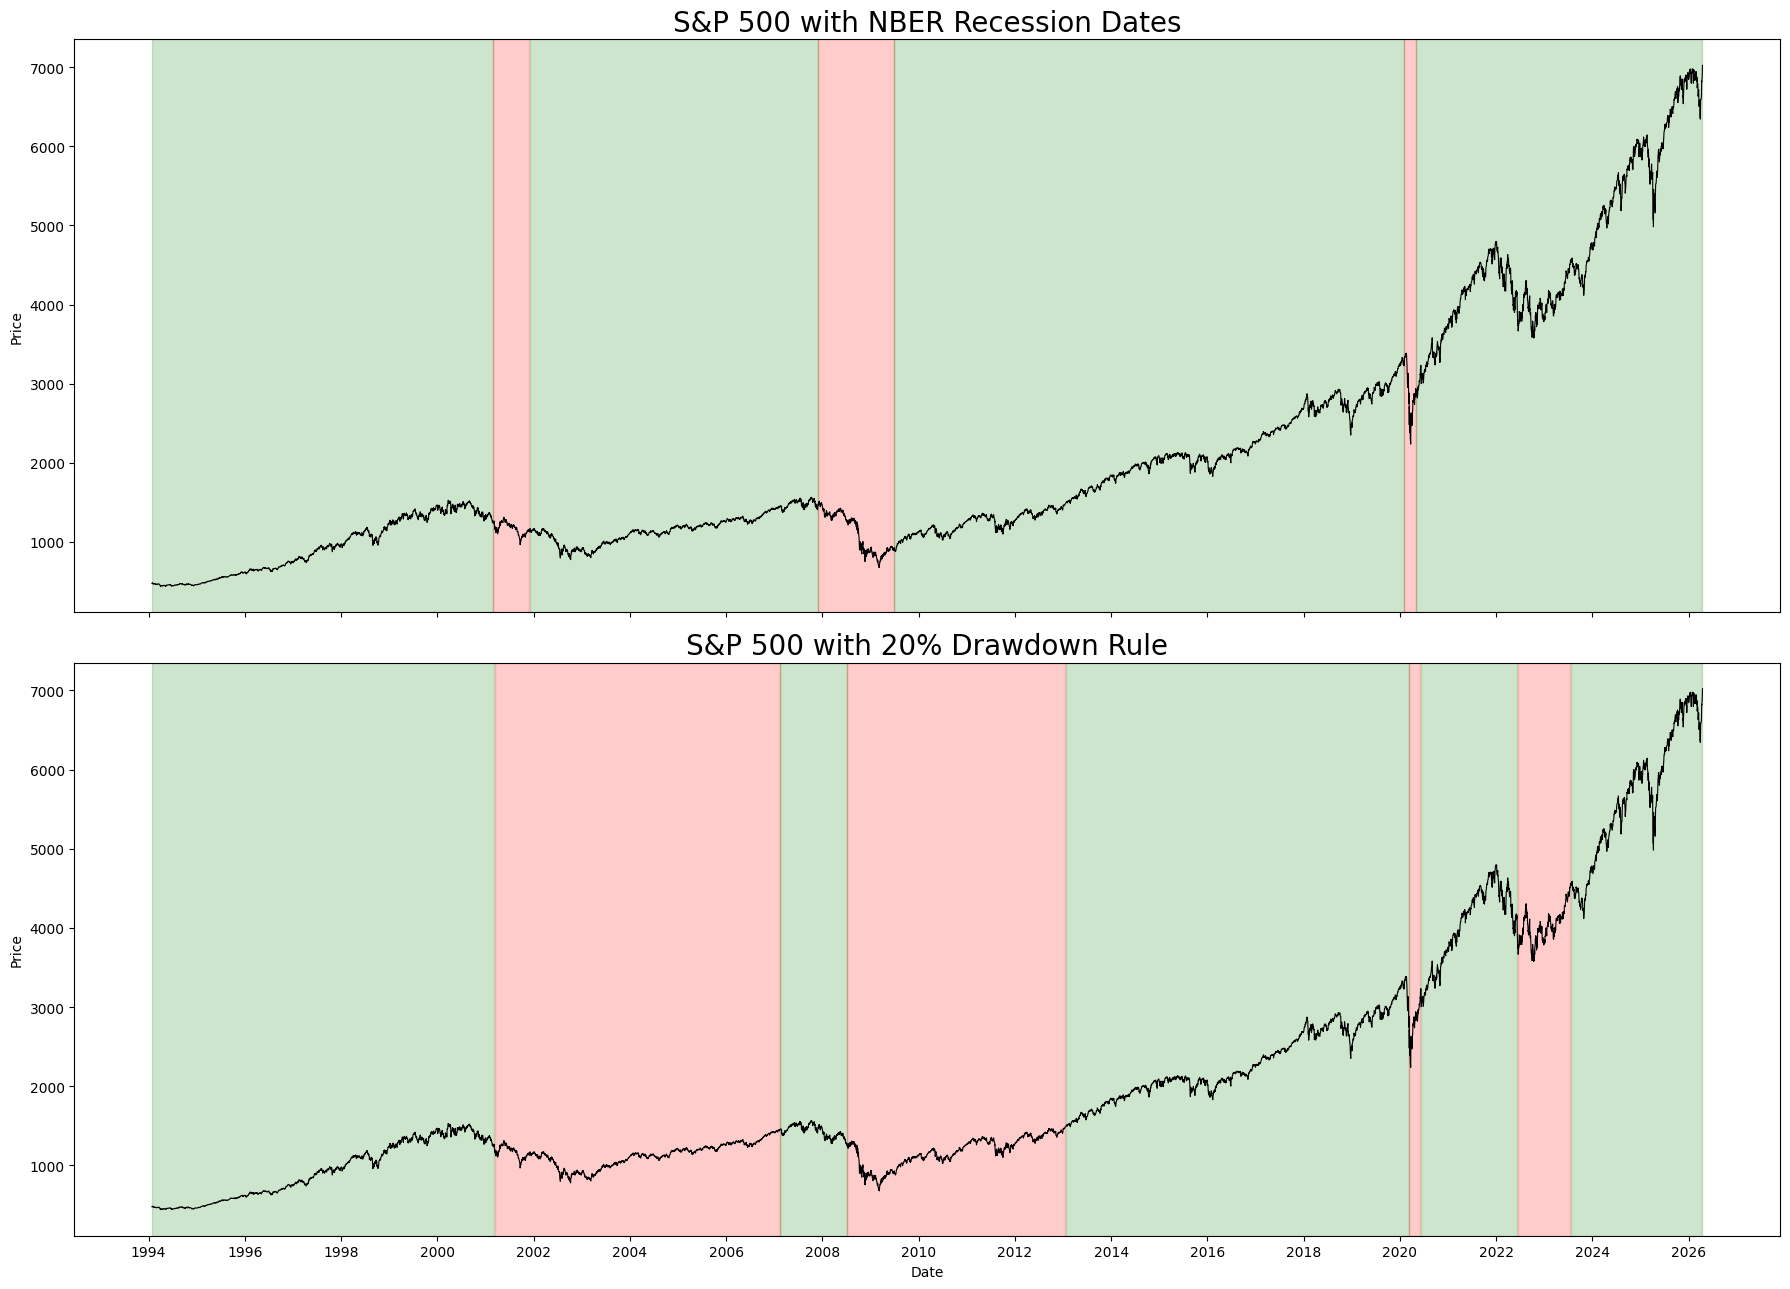

In [429]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =============================================================================
# VISUAL COMPARISON: GMM + HMM + CHANGEPOINT (PELT) vs NBER vs 20% DRAWDOWN
# =============================================================================

# Load the other model predictions
hmm_df = pd.read_csv('../../../data/multivariate_hmm_labeled_dataset.csv')
changepoint_df = pd.read_csv('../../../data/multivariate_changepoint_labeled_dataset.csv')

hmm_df['Date'] = pd.to_datetime(hmm_df['Date'])
changepoint_df['Date'] = pd.to_datetime(changepoint_df['Date'])

# Merge onto current GMM dataframe
# Assumes df_work already contains:
#   - Date
#   - price_col
#   - regime              -> GMM labels
#   - nber_regime
#   - drawdown_regime
df_plot = df_work.merge(
    hmm_df[['Date', 'regime']].rename(columns={'regime': 'regime_hmm'}),
    on='Date',
    how='inner'
)

df_plot = df_plot.merge(
    changepoint_df[['Date', 'regime']].rename(columns={'regime': 'regime_changepoint'}),
    on='Date',
    how='inner'
)

fig, axes = plt.subplots(2, 1, figsize=(18, 13), sharex=True)

# =============================================================================
# Helper functions
# =============================================================================
def shade_full(ax, df, regime_col, alpha=0.2):
    changes = (df[regime_col] != df[regime_col].shift(1)).cumsum()
    for _, group in df.groupby(changes):
        s = group['Date'].iloc[0]
        e = group['Date'].iloc[-1]
        r = group[regime_col].iloc[0]
        ax.axvspan(s, e, color='green' if r == 'bull' else 'red', alpha=alpha)

def shade_band(ax, df, regime_col, ymin, ymax, alpha=0.22):
    changes = (df[regime_col] != df[regime_col].shift(1)).cumsum()
    for _, group in df.groupby(changes):
        s = group['Date'].iloc[0]
        e = group['Date'].iloc[-1]
        r = group[regime_col].iloc[0]
        ax.axvspan(
            s, e,
            ymin=ymin, ymax=ymax,
            color='green' if r == 'bull' else 'red',
            alpha=alpha
        )

# =============================================================================
# 1) Top panel: GMM + HMM + PELT stacked
# =============================================================================
# ax = axes[0]
# ax.plot(df_plot['Date'], df_plot[price_col], color='black', linewidth=0.8)
# ax.set_title('S&P 500 with GMM, HMM, and Changepoint (PELT) Regimes', fontsize=20)
# ax.set_ylabel('Price')

# # Top third: GMM (already in df_work['regime'])
# shade_band(ax, df_plot, 'regime', ymin=0.68, ymax=1.00)

# # Middle third: HMM
# shade_band(ax, df_plot, 'regime_hmm', ymin=0.34, ymax=0.66)

# # Bottom third: Changepoint / PELT
# shade_band(ax, df_plot, 'regime_changepoint', ymin=0.00, ymax=0.32)

# ax.text(0.01, 0.93, 'Top band: GMM', transform=ax.transAxes, fontsize=15)
# ax.text(0.01, 0.48, 'Middle band: HMM', transform=ax.transAxes, fontsize=15)
# ax.text(0.01, 0.03, 'Bottom band: Changepoint (PELT)', transform=ax.transAxes, fontsize=15)

# =============================================================================
# 2) NBER
# =============================================================================
ax = axes[0]
ax.plot(df_plot['Date'], df_plot[price_col], color='black', linewidth=0.8)
ax.set_title('S&P 500 with NBER Recession Dates', fontsize=20)
ax.set_ylabel('Price')
shade_full(ax, df_plot, 'nber_regime')

# =============================================================================
# 3) 20% Drawdown
# =============================================================================
ax = axes[1]
ax.plot(df_plot['Date'], df_plot[price_col], color='black', linewidth=0.8)
ax.set_title('S&P 500 with 20% Drawdown Rule', fontsize=20)
ax.set_ylabel('Price')
shade_full(ax, df_plot, 'drawdown_regime')

# =============================================================================
# Formatting
# =============================================================================
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].set_xlabel('Date')

plt.tight_layout()
plt.savefig('multivariate_gmm_regime_segmentation.png', dpi=300)
plt.show()

In [423]:
import os

# Create directory if it doesn't exist
os.makedirs('reports/coursework', exist_ok=True)

# Save figure
plt.savefig('reports/coursework/regime_comparison.pdf', bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>